1. What is machine learning, and what is our goal here? In your own words, define the goal
of machine learning (briefly). What kind of prediction could we make using this dataset?
What variable seems like a good target?
2. Do some preliminary data summary analysis based on some of the skills you learned
from W2.
3. Train-Test Split: In ML, we split data into a training set (to teach the model) and a test set
(to see how it does on new, unseen data). Split your data so that 80% is training and 20%
is testing. Use train_test_split from sklearn. Use 'danceability' as your target (Y) and
choose at least 3 numerical features as your input (X).
4. Linear Regression Model: Fit a linear regression model to your training data. Call this
model 'model1' . Print the coefficients and intercept. What do they tell you about the
relationship between the inputs and the target? Interpret them!
5. Plot the Predictions: Plot the predicted vs actual values using a scatter plot. What kind of
pattern would you expect if the model was very accurate?
6. Try a Smaller Training Set?: Repeat the train/test split with only 20% of data as training
and 80% as testing. Fit and evaluate your model again. Call this model 'model2'. How's
the accuracy now?
7. Try More Features: Try using more features (all available numeric ones) in your X. Call
this model 'model3'. Re-run the model. What is your accuracy now?
8. Check Feature Correlation: Use a correlation matrix to check which features are most
related to 'danceability'. Plot a correlation heatmap using sns.heatmap(). Which features
are most strongly correlated with danceability (positively or negatively)? Should we
include them in our model?
9. Reflect: How Do We Make a Good Model? Write 2–3 sentences on what makes a model
good. What would you do next if you were trying to make this prediction model even
better?
10. Clearly, just using accuracy might not be the best way to evaluate a model when it's a
linear regression. Look up 'R^2' and the 'MSE' (hint, we use these as another way to
evaluate how good our linear models are). If you can, go through models 1-3 and find
their R^2 and their MSEs, and interpret them. Which model, in your opinion, is the 'best'?
Try to make a clean table that shows the outputs and different accuracy measurements for
your models for this final comparison.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("Spotify_top_2019.csv")

In [3]:
#Our goal here is being able to predict patterns, and with this dataset we can predict things like common genres
print(df.head())

                      id                                           name  \
0  6v3KW9xbzN5yKLt9YKDYA                                       Señorita   
1  2Fxmhks0bxGSBdJ92vM42                                        bad guy   
2  0RiRZpuVRbi7oqRdSMwhQ  Sunflower - Spider-Man: Into the Spider-Verse   
3  6ocbgoVGwYJhOv1GgI9Ns                                        7 rings   
4  2YpeDb67231RjR0MgVLzs                          Old Town Road - Remix   

         artists  danceability  energy  key  loudness  mode  speechiness  \
0   Shawn Mendes         0.759   0.548  9.0    -6.049   0.0       0.0290   
1  Billie Eilish         0.701   0.425  7.0   -10.965   1.0       0.3750   
2    Post Malone         0.755   0.522  2.0    -4.368   1.0       0.0575   
3  Ariana Grande         0.778   0.317  1.0   -10.732   0.0       0.3340   
4      Lil Nas X         0.878   0.619  6.0    -5.560   1.0       0.1020   

   acousticness  instrumentalness  liveness  valence    tempo  duration_ms  \
0        0.039

In [4]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0
mean,0.719400,0.60462,5.280000,-6.229000,0.580000,0.127582,0.299381,0.006039,0.132792,0.490460,120.425700,201691.620000,4.0
std,0.130358,0.16975,3.295266,2.725249,0.498569,0.103008,0.255321,0.029065,0.074088,0.219144,28.740856,44213.177325,0.0
min,0.351000,0.11100,0.000000,-14.505000,0.000000,0.029000,0.005130,0.000000,0.057400,0.120000,71.105000,113000.000000,4.0
25%,0.657500,0.52000,2.000000,-7.056000,0.000000,0.053675,0.095900,0.000000,0.088425,0.330500,97.316000,175840.000000,4.0
50%,0.743000,0.62400,5.000000,-5.759000,1.000000,0.081350,0.244000,0.000000,0.106000,0.495000,116.125500,193657.500000,4.0
75%,0.814500,0.73225,8.000000,-4.295250,1.000000,0.199000,0.449250,0.000003,0.141250,0.637000,137.478750,215372.250000,4.0
max,0.907000,0.90400,11.000000,-2.652000,1.000000,0.375000,0.978000,0.162000,0.437000,0.952000,179.974000,354320.000000,4.0


In [5]:
X_df = df[['energy','instrumentalness','speechiness']]
X_df.shape

(50, 3)

In [6]:
y_df = df['danceability']
y_df.shape

(50,)

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X_df, y_df, test_size=0.2, random_state=1)

In [9]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression(fit_intercept=True)
model1.fit(Xtrain, ytrain)
ypred= model1.predict(Xtest)

In [10]:
model1.coef_


array([0.20997458, 0.7743659 , 0.13809735])

In [11]:
model1.intercept_

np.float64(0.5664584424855157)

In [12]:
from sklearn.metrics import r2_score
r2_score(ytest, ypred)

0.24473392405318195

In [13]:
from sklearn.metrics import mean_squared_error
mean_squared_error(ytest,ypred)

0.015280278905429445

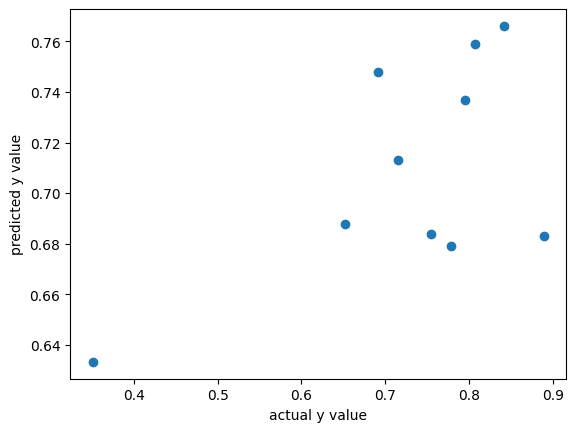

In [14]:
plt.scatter(ytest, ypred)
#plt.plot(ytest, ypred)
plt.xlabel('actual y value')
plt.ylabel('predicted y value')
plt.show()

In [15]:
X_df2 = df[['energy','instrumentalness','speechiness']]
y_df2 = df['danceability']


In [16]:
Xtrain2, Xtest2, ytrain2, ytest2 = train_test_split(X_df2, y_df2, test_size=0.8, random_state=1)

In [17]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression(fit_intercept=True)
model2.fit(Xtrain2, ytrain2)
ypred2= model2.predict(Xtest2)

In [18]:
model2.intercept_

np.float64(0.3690266874145408)

In [19]:
model2.coef_

array([   0.49129312, -480.81498727,    0.81567334])

In [29]:
mean_squared_error(ytest2,ypred2)

249.50647575534543

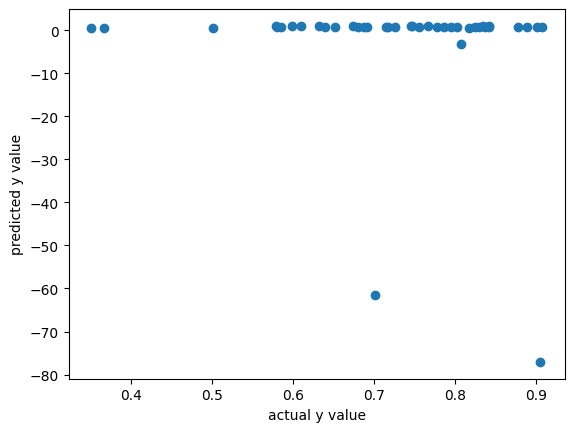

In [20]:
plt.scatter(ytest2, ypred2)
#plt.plot(ytest, ypred)
plt.xlabel('actual y value')
plt.ylabel('predicted y value')
plt.show()
#clearly insanely innacurate compared to previous graph

In [21]:
X_df3 = df.drop(columns=['id','name','artists'])
y_df3 = df['danceability']

In [22]:
Xtrain3, Xtest3, ytrain3, ytest3 = train_test_split(X_df3, y_df3, test_size=0.2, random_state=1)
model3 = LinearRegression(fit_intercept=True)
model3.fit(Xtrain3, ytrain3)
ypred3= model3.predict(Xtest3)

In [23]:
model3.coef_


array([ 1.00000000e+00, -3.09897224e-16, -1.37821130e-16,  5.81409122e-17,
        6.60853102e-18, -4.04568707e-16, -5.94735764e-17, -1.01981598e-16,
       -1.61365367e-16,  2.72871266e-16, -2.02810547e-17,  1.69193475e-19,
        0.00000000e+00])

In [24]:
model1.intercept_

np.float64(0.5664584424855157)

In [25]:
r2_score(ytest3, ypred3)
#So a higher amount of testing data can produce a really accurate model

1.0

In [30]:
mean_squared_error(ytest3,ypred3)

3.484669789297379e-29

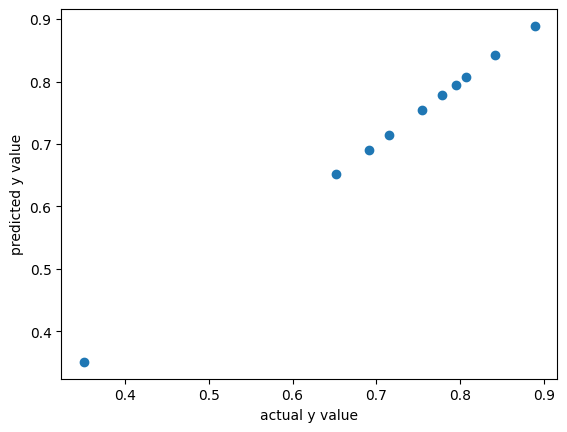

In [26]:
plt.scatter(ytest3, ypred3)
#plt.plot(ytest, ypred)
plt.xlabel('actual y value')
plt.ylabel('predicted y value')
plt.show()

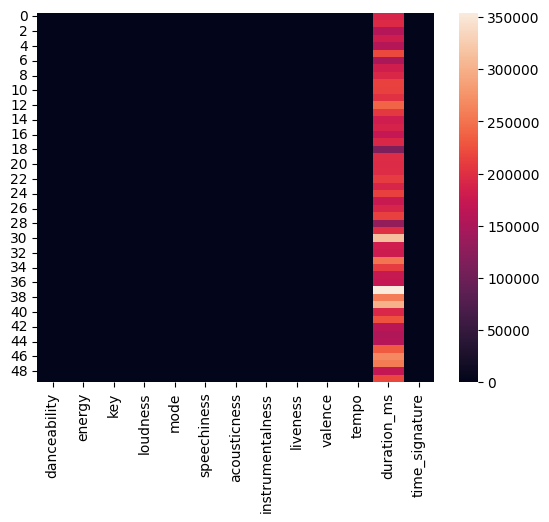

In [27]:
sns.heatmap(X_df3)
plt.show()

In [28]:
#so, to make a good model I need to have a lot of data going in, and also make sure that the test size is much smaller than the training size.